# **Assignment 4**
This exercise has two parts:

- Part A consists of mandatory exercises; you need to complete these and hand in your answers to be able to partake in the exam. This part also provides you with an impression of the minimum knowledge level necessary to pass the exam.
- Part B consists of additional exercises. These repeat a concept that is covered in Part A or help to broaden or deepen your understanding of some of the topics.

## Assignment by
Lan Stare, s1169977

Aaron Ritz, s1170346

# **Part A** - Mandatory Exercises
Below you will find the mandatory exercises for Week 4 of the course Data Mining and Machine Learning.

## **Exercise 1** - Exercise 7 on Page 550 in Section 6.14 from TSKK

#### (a):
$P(A = 1 | +) = 3/5, P(B = 1 | +) = 1/5, P(C = 1 | +) = 4/5, P(A = 1 | -) = 2/5, P(B = 1 | -) = 2/5, P(C = 1 | -) = 1$

#### (b):
First we need to calculate: $P(A = 0 | +) = 1 - P(A = 1 | +) = 2/5$ and $P(C = 0 | +) = 1 - P(C = 1 | +) = 1/5$ and $P(A = 0 | -) = 3/5$ and $P(C = 0 | -) = 0$
We will use the Bayes theorem for classification: $P(class = + | A = 0, B = 1, C = 0) = \frac{P(A = 0 | class = +)P(B = 1 | class = +)P(C = 0 | class = +)P(class = +)}{P(A = 0 | class = +)P(B = 1 | class = +)P(C = 0 | class = +)P(class = +)  +  P(A = 0 | class = -)P(B = 1 | class = -)P(C = 0 | class = -)P(class = -)}$
where we have assumed the conditional independance of attribute values. Solving this equation we get the probability that the test sample (A = 0, B = 1, C = 0) has a class label +: $$ P(class = + | A = 0, B = 1, C = 0) = \frac{2/5 * 1/5 * 1/5 * 1/2}{2/5 * 1/5 * 1/5 * 1/2 + 0} = 1 $$ In a similar manner (changing + and -) we can predict the possibility that the test sample has a class label -: $$ P(class = - | A = 0, B = 1, C = 0) = 0 $$ We can therefore assign the test sample to class +.

#### (c):
Conditional probabilities with m-estimate approach: P(A | Class = +) = $\frac{3 + 4*1/2}{5 + 4} = 5/9$. Similarly we can calculate other probabilities:
P(B | class = +) = $1/3$, P(C | class = +) = $2/3$, P(A | class = -) = $4/9$, P(B | class = -) = $4/9$, P(C | class = -) = $7/9$

#### (d):
Firstly we check for class +: $$ P(class = + | A = 0, B = 1, C = 0) = \frac{(1 - 5/9) * 1/3 * (1 - 2/3) * 1/2}{0 * 1/2  + 1/5 * 1/2} \approx 0.473 $$
For the class -: $$  P(class = - | A = 0, B = 1, C = 0) \approx 0.527 $$ We can therefore assign the test sample to class -.

#### (e):
The Naive Bayers method is usually good when we have a lot of training examples, which is not the case here. The problem is that out of these 10 examples we have no example of C = 0 when class = -. Due to this the whole probability became 0 leading to 100 % chance of the test sample being assigned class +. When we first estimated the values using m-estimate, we removed our zero probability, producing a more realistic and stable model.


## **Exercise 2** - LDA
Let usconsider some basics of linear discriminant analysis in one dimension on the real line.

**a.** Plot two normal distributions in one dimension.  One should be the standard normal, while the other should have mean 2 and variance 1.

The two curves give the distributions for the red class and the blue class, respectively, i.e., the plot gives the class-conditional distributions.

The decision boundary is located at those $x$ on the real line where the classifier changes its decision from one into the other class.  Typically, for probabilistic classifiers, at these points, the posterior class probability $P(\text{class}|\text{attributes})$ is equal for at least two classes.

**b.** In your plot, why is the decision boundary between the red and the blue class not necessarily located at the intersecton of the two curves you plotted?

**c.** Assume both prior class probabilities are equal.  Where is the decision boundary located?  [You can do the explicit calculation or make a reasonable guess based on the locations of the means, the variances being equal, and the symmetry of the normal distributions.]

**d.** Now take $P(\text{blue}) = \frac{1}{3}$, where is the decision boundary located now?  Maybe you don't want to go through the whole derivation, but at least try to see 1) which equation you need to solve for this and 2) in which direction the decision boundary will shift compared to the one in **c**.

**e.** Now make another plot with the class-conditional distribution _multiplied_ [or weighted] with their respective priors, which are $P(\text{red}) = \frac{2}{3}$ and $P(\text{blue}) = \frac{1}{3}$ in this case.

**f.** At which $x$ do the blue and the red curve intersect?

**g.** By merely changing the prior probabilities of the two classes, red and blue, which points on the real line can become the decision boundary?

**h.** Assume now there is a third class, the green one, which is also normally distributed with a variance of 1.  The mean of the green class is 4.  Assume that all class priors are equal.  Which point is not a decision boundary, even though two of the posterior class probabilities are equal at that point?

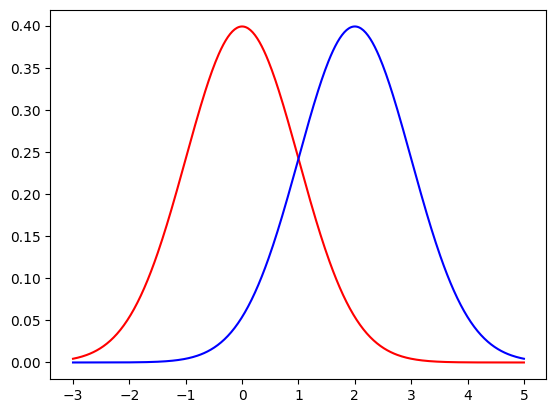

In [35]:
""" (a) """
import matplotlib.pyplot as plt
import numpy as np
import math
import scipy.stats as stats

mu1 = 0
variance = 1
mu2 = 2
sigma = math.sqrt(variance)
x1 = np.linspace(mu1 - 3*sigma, mu2 + 3*sigma, 400)
plt.plot(x1, stats.norm.pdf(x1, mu1, sigma), color='red') #first plotting the standard normal distribution
plt.plot(x1, stats.norm.pdf(x1, mu2, sigma), color='blue') #then plotting the other gaussian
plt.show()

#### (b)
Because we don't know how the two functions are weighted (prior class probabilities).

#### (c)
the decision boundary when both probabilities are equal is at x = 1, because the mean of the red distribution is 0 and the mean of the blue distrubution is 2. Since the variances and prior probabilities are equal, the decision boundary is 1.

#### (d)
You need to solve the equation: P(x | mu2, sigma)P(blue) = P(x | mu1, sigma)P(red), which translates to: 1/3 * P(x | mu2, sigma) = 2/3 * P(x | mu1, sigma). This is due to the prior probability of blue being 1/3 and of red being 2/3. So the ratio between them is 1 : 2. This will lead to decision boundary being shifted to the right (into the blue curve), because there will be a higher probability of an element being in the red class rather than in the blue one.

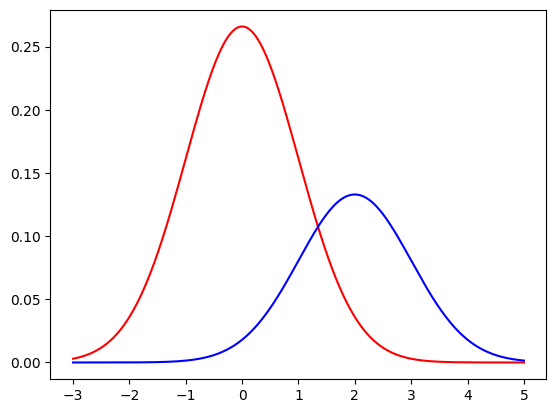

In [44]:
""" (e) """

import matplotlib.pyplot as plt
import numpy as np
import math
import scipy.stats as stats

mu1 = 0
variance = 1
mu2 = 2

sigma = math.sqrt(variance)
x = np.linspace((mu1 - 3*sigma), (mu2 + 3*sigma), 400)
plt.plot(x, stats.norm.pdf(x, mu1, sigma)*2/3, color='red')
plt.plot(x, stats.norm.pdf(x, mu2, sigma)*1/3, color='blue') #so we added the priors (factors) 1/3 and 2/3
plt.show()

In [48]:
""" (f) """
import math

# Parameters
mu_red = 0      
mu_blue = 2      
sigma2 = 1  
P_red = 2/3
P_blue = 1/3

# For equal variance Gaussians, the solution simplifies to:
x_boundary = (mu_red + mu_blue)/2 + (sigma2 / (mu_blue - mu_red)) * math.log(P_red / P_blue)

print(x_boundary)
#We can see that the decision boundary is approximately at x = 1.34657


1.3465735902799727


#### (g)
Since the means are 0 and 2 and variance is the same, only the first factor in our boundary calculation is fixed. When P_red is much bigger than P_blue, logarithm converges to $\infty$. This means that also x (our decision boudary) converges to $\infty$. When P_red is much smaller than P_blue, logarithm converges to $-\infty$, which means that also our x converges to $-\infty$. This means, that our decision boundary can take any real number even though our means and variances are fixed.

#### (h)
When x = 2 the red and green curve intercept, but this is not the decision boundary, since values on either side of this boundary (for small x) all belong to the blue class. So the class doesn't change when we cross this point, meaning that it is not a decision boundary.

## **Exercise 3** - Linearity

In linear discriminant analysis, linear refers to the decision boundary being linear.  In the two-class case, any linear boundary is defined by all points $x \in \mathbb{R}^d$ for which $w^Tx + w_\circ = 0$ for some vector $w \in \mathbb{R}^d$ and scalar $w_\circ \in \mathbb{R}$.

Consider 2-class LDA. Let $C$ be the covariance matrix of the two classes 1 and 2, let $m_1$ and $m_2$ be the two class means, and let $p_1$ and $p_2$ their respective prior probabilities.  For this setting, we can express the scalar $w_\circ$ and the vector $w$ in these terms.  Show that $w=C^{-1}(m_1-m_2)$ and $w_\circ = -\frac{1}{2} m_1^TC^{-1}m_1 + \frac{1}{2} m_2^TC^{-1}m_2+\log \frac{p_1}{p_2} $.

![title](proof_3ex.JPEG)

## **Exercise 4** - Some https://scikit-learn.org/

Have a look at https://scikit-learn.org/stable/auto_examples/classification/plot_lda_qda.html, which considers linear and quadratic discriminant analysis.  The website shows how to use scikit-learn's LDA and illustrates some decision boundaries.  You can investigate what happens to the solutions when you change the data, e.g., when you resample the data or even use other distributions than normal ones.  

**a.** Recreate the middle two plots and plot nine [i.e., 9] additional decision boundaries that have been obtained using nine new synthetic training datasets from the same distribution.

**b.** Make the same plot as under **a**, however, change ```n_samples``` to something much smaller, e.g., 10 or so.

**c.** What seems to happen with different sample sizes?  Will you get the same decision boundary every time you rerun the experiment?  How similar are LDA and QDA for small sample sizes?  Why does this happen?

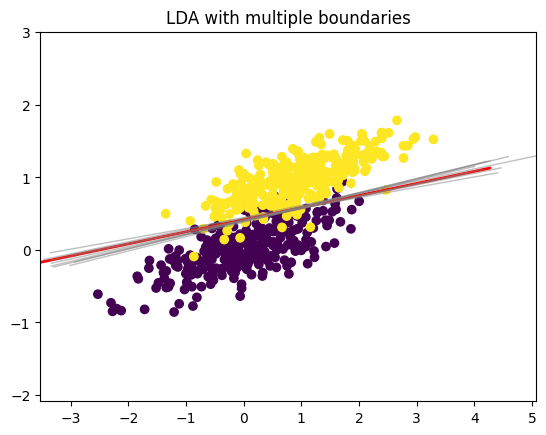

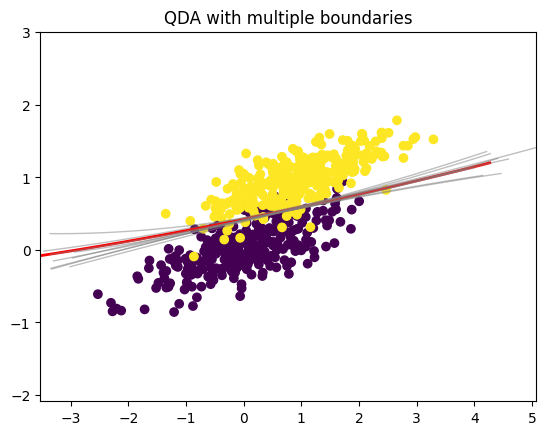

In [51]:
# Task A
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis,
    QuadraticDiscriminantAnalysis,
)

# copied from documentation:
def make_data(n_samples, cov1, cov2, seed=0):
    rng = np.random.RandomState(seed)
    X = np.concatenate([
        rng.randn(n_samples, 2) @ cov1,
        rng.randn(n_samples, 2) @ cov2 + np.array([1, 1])
    ])
    y = np.concatenate([np.zeros(n_samples), np.ones(n_samples)])
    return X, y

# covariance matrices 
cov1 = np.array([[0.0, -0.23], [0.83, 0.23]])
cov2 = cov1.copy() 

# plot multiple boundaries
def plot_multiple_boundaries(ModelClass, n_samples=300, title=""):
    
    X, y = make_data(n_samples, cov1, cov2, seed=0)
    fig, ax = plt.subplots()
    # Plot scatter
    ax.scatter(X[:, 0], X[:, 1], c=y)
    # Plot base boundary
    estimator = ModelClass().fit(X, y)
    DecisionBoundaryDisplay.from_estimator(estimator, X, response_method="predict_proba",
                                           plot_method="contour", ax=ax, levels=[0.5], colors="red", linewidths=2)
    # Overlay 9 more boundaries
    for seed in range(1, 10):
        Xs, ys = make_data(n_samples, cov1, cov2, seed=seed)
        est = ModelClass().fit(Xs, ys)
        DecisionBoundaryDisplay.from_estimator(est, Xs, response_method="predict_proba",
                                               plot_method="contour", ax=ax, levels=[0.5], alpha=0.5,
                                               colors="gray", linewidths=1)
    ax.set_title(title)
    plt.show()

# Use it
plot_multiple_boundaries(LinearDiscriminantAnalysis, n_samples=300, title="LDA with multiple boundaries")
plot_multiple_boundaries(QuadraticDiscriminantAnalysis, n_samples=300, title="QDA with multiple boundaries")

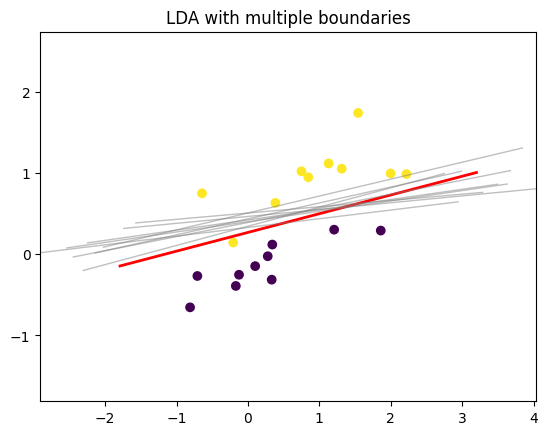

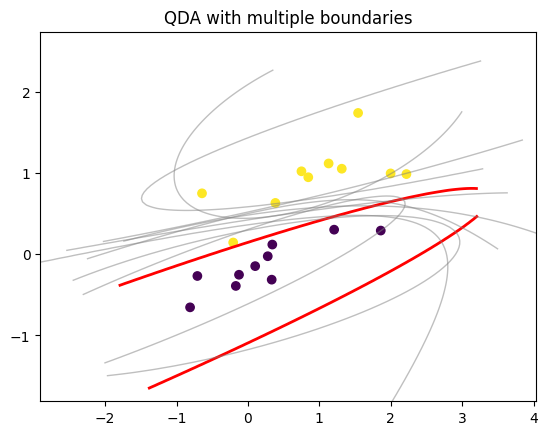

In [52]:
plot_multiple_boundaries(LinearDiscriminantAnalysis, n_samples=10, title="LDA with multiple boundaries")
plot_multiple_boundaries(QuadraticDiscriminantAnalysis, n_samples=10, title="QDA with multiple boundaries")

**Answer C:**

$var = Σ(xi - x̄)² / (n - 1)$    &ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;(1D case)

As you can see, the smaller the number of samples, the higher the variance in the data.
Especially at N=10, we cannot leverage the CLT, so the distributions you can derive from the amount of data we have vary a lot - so do the decision boundaries.


Also QDA has more parameters, making it more unstable at small N.

## **Exercise 5** - A Linear Decision Boundary

Show that logistic regression gives a linear decision boundary.

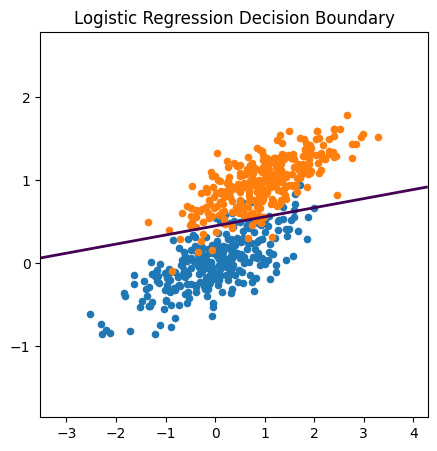

In [54]:
from sklearn.linear_model import LogisticRegression

cov1 = np.array([[0.0, -0.23], [0.83, 0.23]])
cov2 = cov1.copy() 
# toy 2D data
X, y = make_data(300, cov1, cov2)

# fit logistic regression
clf = LogisticRegression().fit(X, y)

# grid
x1 = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 200)
x2 = np.linspace(X[:,1].min()-1, X[:,1].max()+1, 200)
xx1, xx2 = np.meshgrid(x1, x2)
grid = np.c_[xx1.ravel(), xx2.ravel()]

# predicted probability for class 1
proba = clf.predict_proba(grid)[:, 1].reshape(xx1.shape)

# plot data
plt.figure(figsize=(5,5))
plt.scatter(X[y==0,0], X[y==0,1], s=20)
plt.scatter(X[y==1,0], X[y==1,1], s=20)

# boundary

plt.contour(xx1, xx2, proba, levels=[0.5], linewidths=2)
plt.title("Logistic Regression Decision Boundary")
plt.show()

## **Exercise 6** - Naive Bayes

Load the data from ```data/raisin_grains.csv``` in a Dataframe. Store target variable class in ```y``` and the other features in ```x```.

**a.** Calculate the means and standard deviations for every feature per class.

In [55]:
##Answer to Exercise 6
import pandas as pd
import numpy as np
import csv

np.random.seed(0)

data = pd.read_csv("raisin_grains.csv")
print()
y = data["Class"]
x = data.drop(columns=["Class"])
data_means = x.groupby(y).mean()
data_std = x.groupby(y).std()


print("means: \n", data_means)
print("std: \n", data_std)

# YOUR CODE HERE


means: 
                   Area  MajorAxisLength  MinorAxisLength  Eccentricity  \
Class                                                                    
Besni    112194.788889       509.000652       279.623674      0.821125   
Kecimen   63413.466667       352.859249       229.352592      0.741960   

            ConvexArea    Extent    Perimeter  
Class                                          
Besni    116675.824444  0.691242  1348.127036  
Kecimen   65696.355556  0.707774   983.686236  
std: 
                  Area  MajorAxisLength  MinorAxisLength  Eccentricity  \
Class                                                                   
Besni    39229.897872       105.771154        50.763657      0.068277   
Kecimen  17727.768795        59.611494        34.058657      0.092362   

           ConvexArea    Extent   Perimeter  
Class                                        
Besni    40797.067805  0.060827  246.804611  
Kecimen  19005.891848  0.043442  150.305531  


**b.** Show the number of classes using ```sns.countplot``` and features using ```sns.pairplot```.

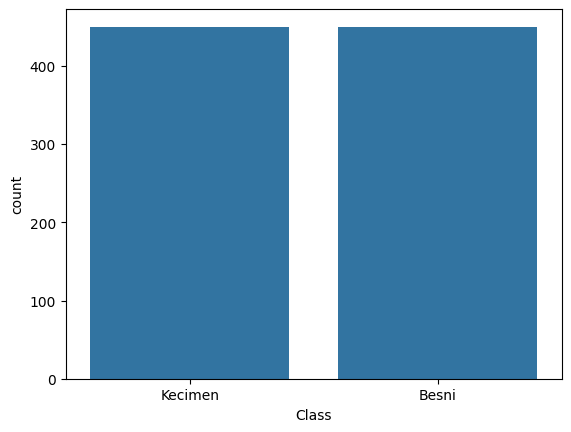

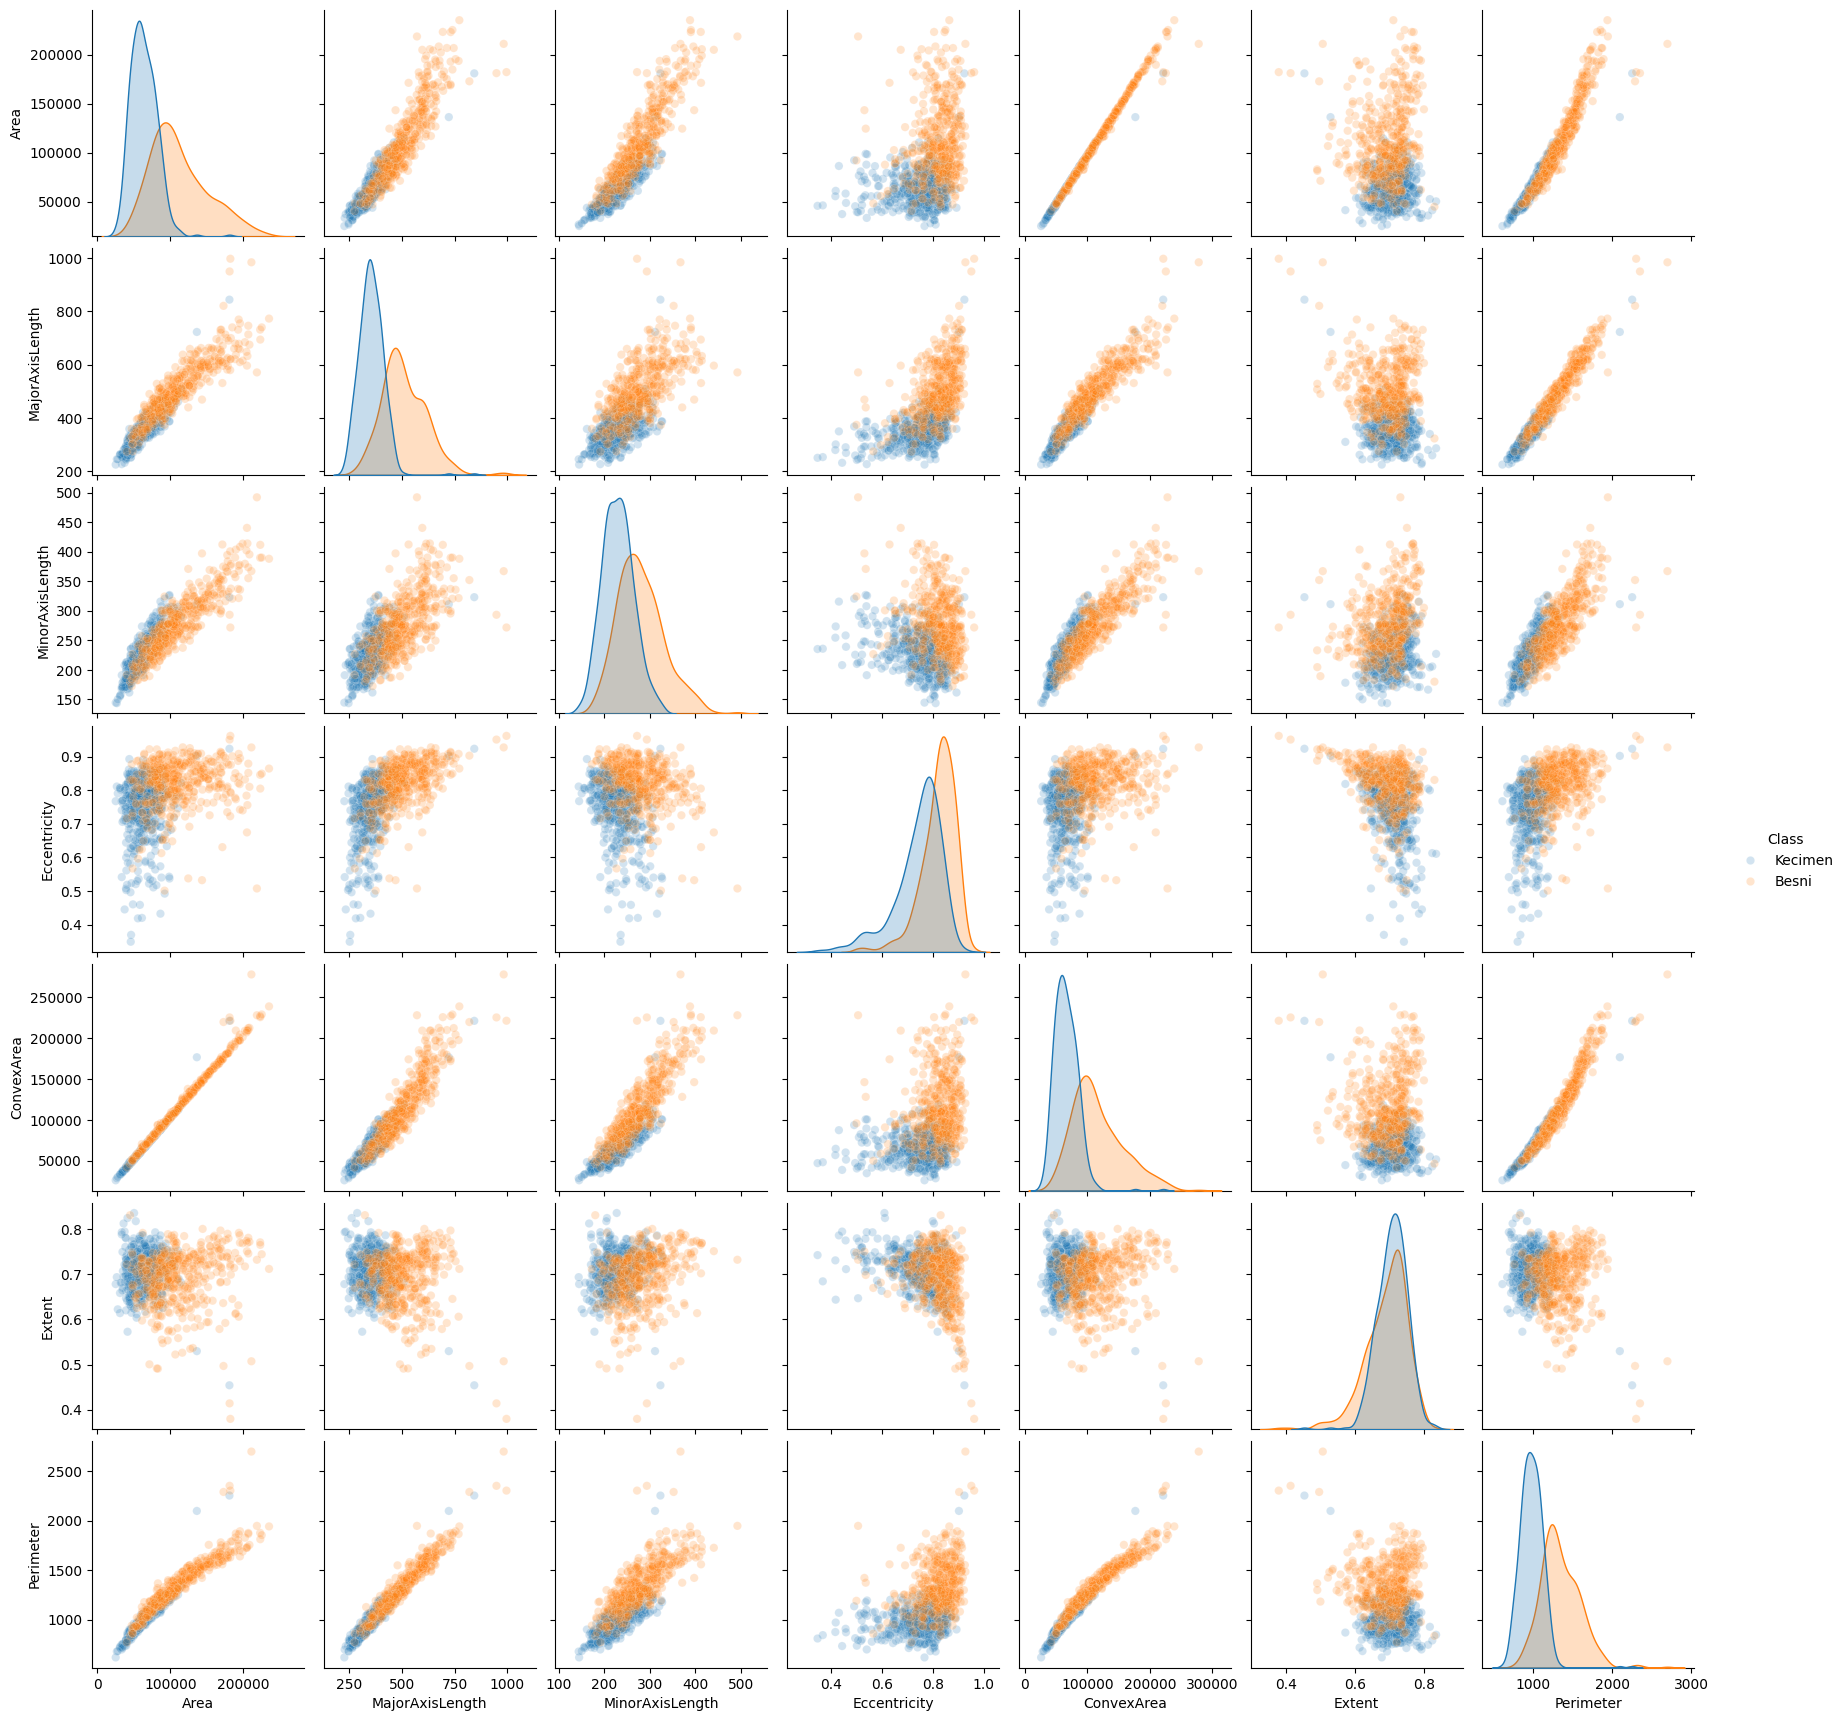

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x = y)
sns.pairplot(data, hue="Class", plot_kws={"alpha": 0.2})

**c.** Show the correlations between pairs of features using ```sns.heatmap```.

<Axes: >

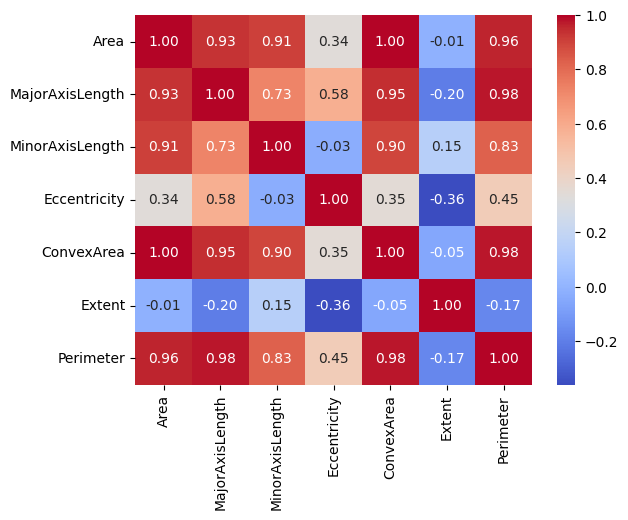

In [57]:
sns.heatmap(x.corr(), annot=True, fmt=".2f", cmap="coolwarm", cbar=True)

Train a Naive Bayes model using a train and test split for the dataset [see  https://scikit-learn.org/stable/modules/naive_bayes.html].  You could split the data 50-50, but make sure you split it randomly.

**d.** Give the accuracies of the train and test sets.

In [59]:
from sklearn.naive_bayes import GaussianNB
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

np.random.seed(0)

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.5, random_state=0, shuffle=True
)

naivebayes = GaussianNB()
naivebayes.fit(X_train, y_train)

train_acc = accuracy_score(y_train, naivebayes.predict(X_train))
test_acc = accuracy_score(y_test, naivebayes.predict(X_test))
accuracy_nb = (train_acc, test_acc)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")


Train Accuracy: 0.8222
Test Accuracy:  0.8244


**e.** Why is naive bayes "naive"?

Because it naively assumes that the attribute values are conditionally independent of each other.

**f.** Does the naive assumption holds for the raisins dataset?

No, many features are highly correlated. This makes me think though - observing them, they look like they might just be measuring the same properties. So maybe something like PCA beforehand could be handy?

# **Part B**

## **Exercise 7** - Independence

Given three binary attributes $A$, $B$, and $C$.  The joint probability distribution is given by
$$
P(A,B,C) =
\begin{cases}
    \frac{1}{4}& \text{if the sum of the three attributes is even or zero}\\
    0             & \text{otherwise.}
\end{cases}
$$

**a.** Show that $P(A,B) = P(A)P(B)$, i.e., $A$ and $B$ are independent.


**b.** Show that $A$ and $B$ are _not_ conditionally independent given $C$.

## **Exercise 8** - More Independence?

Consider a 2-dimensional multivariate Gaussian distribution for a variable $x \in \mathbb{R}^2$.  Assume its mean equals $m = (m_1,m_2)^T$ and its covariance matrix $C$ is diagonal, i.e. it is of the form
$$
C = \begin{pmatrix}
c_1 & 0 \\
0 & c_2
\end{pmatrix} .
$$

**a.** Show that its density function
$$
\frac{1}{2 \pi \sqrt{|C|}} \exp\left[-\frac{1}{2}(x-m)^T C^{-1} (x-m)\right]
$$
equals the product of the two 1-dimensional Gaussians given by mean $m_1$ and variance $c_1$ and by mean $m_2$ and variance $c_2$, respectively.

**b.** Does this mean that the two variables $x_1$ and $x_2$ are independent of each other?

## **Exercise 9** - LDA's Maximum Likelihood

Consider two-class LDA in one dimension.  Let $\pi_y$ the prior, $m_y$ the mean, and $v$ the variance of class $y$.   The probabilistic model, with $y \in \{1,2\}$, then can be written as
$$
p(x,y) = \frac{p_y}{\sqrt{2 \pi v}} \exp\left[ -\frac{1}{2v}(x-m_y)^2  \right].
$$

Now, given a dataset $D$ with $M$ observations $x_{1,1}, x_{1,2} \ldots, x_{1,N}$ from class 1 and $N$ observations $x_{2,1}, x_{2,2} \ldots, x_{2,M}$ from class 2, then likelihood takes the form
$$
L(p_1,p_2,m_1,m_2,C|D) = \prod_{i=1}^M p(x_i,1) \prod_{j=1}^N p(x_j,2).
$$

Show that the maximum likelihood estimates for the various variables equal $\hat{p}_1 = \frac{M}{M+N}$, $\hat{p}_2 = \frac{N}{M+N}$, $\hat{m}_1 = \frac{1}{M} \sum_{i=1}^M x_{1,i}$, $\hat{m}_2 = \frac{1}{N} \sum_{i=1}^N x_{2,i}$, and $\hat{C} = \hat{p}_1 \hat{v}_1 + \hat{p}_2 \hat{v}_2$, where $\hat{v}_1 = \frac{1}{M} \sum_{i=1}^M (x_{1,i}-\hat{m}_1)^2$ and  $\hat{v}_1 = \frac{1}{N} \sum_{i=1}^N (x_{2,i}-\hat{m}_2)^2$.

## **Exercise 10** - Exploding Logistics

Consider logistic regression in one dimension.  Assume the posterior for class 1 is given by $\frac{1}{1+\exp(-wx)}$ [of course, the posterior of the other class is one minus this expression].  

Note that the linear term $-wx$ in the sigmoid does not contain a scalar offset $w_0$.  As a result, the decision boundary is always located at $x=0$ and we have only one parameter that needs to be estimated, which is $w$..

**a.** Say we have data points $-2$ and $1$ from class 1 and points $-1$ and $2$.from class 2.  Plot the log-likelihood [as a function of $w$] and come to a rough estimate of the optimal parameter value [say, up to one decimal after the dot] by visual inspection of the graph.

**b.** Now take one negative $x$ as the sample from class 1 and one positive $x$ as the sample from class 2. What happens to the log-likelihood when $w$ goes to infinity?  Does this mean [in some sloppy mathematical sense] that $w = \infty$ is the maximum-likelihood estimate?

**c.** What posterior does the model give for the points you chose when $w$ is infinite?  Does that seem reasonable?

## **Exercise 11** - LDA and Logistic

Revisit Exercises 4a and 4b, but substitute QDA by logistic regression [see  https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LogisticRegression.html].

## **Exercise 12** - Sigmoidality

Under the model assumptions that LDA makes and using the notation from Exercise 3, show that the corresponding class posterior $P(\text{class 1}|x)$ is shaped like a sigmoid as a function of $x$.  In other words, show that
$$
P(\text{class 1}|x) = \frac{1}{1+\exp(-w^Tx - w_\circ)}  
$$
for some vector $w \in \mathbb{R}^d$ and scalar $w_\circ \in \mathbb{R}$.

Similar to Exercise 9, though the solution only relies on some elementary steps, this may definitely not be an easy exercise...

## **Exercise 13, 14, and 15** - More from the book...

Make Exercises 6, 8, and 10 on Page 550 in Section 6.14 from TSKK.

## **Exercise 16** - Logistic Regression from Scratch

An implementation of logistic regression from scratch in wich it is trained through gradient descent.

In [ ]:
def sigmoid(x):
    return 1/(1+np.exp(-(x)))

X = (x - x.mean())/(x.std()) #Scaling is important for this implementation
m, n = X.shape
W = np.zeros(n)
B = 0
y_encoded = np.mean([y=="Besni"], axis=0)

learning_rate = 0.001
epochs = 100

mean_errors = []


for e in range(epochs):
    errors = []
    for idx, X_sample in enumerate(X):
        #Get predictions
        predictions = X_sample.dot(W) + B
        #'Normalize' predicted values between 0 and 1
        norm_predictions = sigmoid(predictions)
        #Calculate error
        error = norm_predictions - y_encoded[idx]
        errors.append(error)
        #Calculate gradient direction for weights and bias
        dW = np.dot(X_sample.T, error)
        #Update weight and bias in negative gradient direction
        W = W - learning_rate * dW
        b = B - learning_rate * error
    mean_errors.append(np.mean(errors))
    plt.title("Error logistic regression")
    plt.xlabel("Epoch")
    plt.ylabel("Mean error")
    plt.plot(np.arange(1, len(mean_errors)+1), mean_errors)

Can you identify some crucial differences with scikit-learn's implementation of logistic regression?

# Handing in
Hand in the filled-in notebook:
- Make sure your names and student-numbers are mentioned at the appropriate location at the top of this file.
- Make sure you wrote a serious attempt for all exercises in part A
- Make sure the notebook is named groupnumber_assignment1.ipynb

When you are confident all of this is correctly done, one of you can hand in the exercises in Brightspace!